# Machine Learning Practical Notebook

---
# Practical 1: Random Forest Classifier on Breast Cancer Dataset
---

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==============================================================
# PRACTICAL 1: Random Forest Classifier – Breast Cancer Dataset
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

In [3]:
cancer = load_breast_cancer()

df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target          # 0 = Malignant, 1 = Benign

print(f"Dataset Shape : {df.shape}")
print(f"Class names   : {list(cancer.target_names)}")
print(f"               0 = {cancer.target_names[0]}, 1 = {cancer.target_names[1]}")

Dataset Shape : (569, 31)
Class names   : [np.str_('malignant'), np.str_('benign')]
               0 = malignant, 1 = benign


In [4]:
print("First 5 Rows:")
df.head()

First 5 Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error       

In [6]:
print("Statistical Summary:")
df.describe().round(3)

Statistical Summary:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 455
Testing samples  : 114


In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f"Number of estimators (trees) : {rf.n_estimators}")

Number of estimators (trees) : 100


In [9]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print(f"First 10 predicted labels : {y_pred[:10]}")
print(f"First 10 actual labels    : {y_test.values[:10]}")

Predictions generated.
First 10 predicted labels : [1 0 0 1 1 0 0 0 0 1]
First 10 actual labels    : [1 0 0 1 1 0 0 0 1 1]


## Evaluation Metrics

In [10]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("    EVALUATION METRICS – RANDOM FOREST")
print("=" * 50)
print(f"  Accuracy     : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision    : {prec:.4f}")
print(f"  Recall       : {rec:.4f}")
print(f"  F1-Score     : {f1:.4f}")
print(f"  ROC-AUC      : {auc:.4f}")
print("=" * 50)
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

    EVALUATION METRICS – RANDOM FOREST
  Accuracy     : 0.9649  (96.49%)
  Precision    : 0.9589
  Recall       : 0.9859
  F1-Score     : 0.9722
  ROC-AUC      : 0.9953

Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



---
# Practical 2: Logistic Regression on Diabetes Dataset
---

In [11]:
# ==============================================================
# PRACTICAL 2: Logistic Regression – Diabetes Dataset
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

In [12]:
COLUMNS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    df2 = pd.read_csv('diabetes.csv')
    # Ensure column names are correct
    if list(df2.columns) != COLUMNS:
        df2.columns = COLUMNS
    print(f"Dataset loaded. Shape: {df2.shape}")
except FileNotFoundError:
    print("diabetes.csv not found – generating synthetic demo data.")
    import numpy as np; np.random.seed(42); n = 768
    df2 = pd.DataFrame({
        'Pregnancies': np.random.randint(0, 18, n),
        'Glucose':     np.random.randint(44, 200, n),
        'BloodPressure': np.random.randint(0, 122, n),
        'SkinThickness': np.random.randint(0, 99, n),
        'Insulin':     np.random.randint(0, 846, n),
        'BMI':         np.round(np.random.uniform(0, 67, n), 1),
        'DiabetesPedigreeFunction': np.round(np.random.uniform(0.078, 2.42, n), 3),
        'Age':         np.random.randint(21, 81, n),
        'Outcome':     np.random.randint(0, 2, n)
    })
    print(f"Synthetic dataset created. Shape: {df2.shape}")

diabetes.csv not found – generating synthetic demo data.
Synthetic dataset created. Shape: (768, 9)


In [13]:
print("First 5 Rows:")
df2.head()

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,137,53,85,683,45.3,1.469,55,0
1,14,138,62,4,200,36.6,1.724,50,0
2,10,92,78,54,444,55.6,0.234,48,0
3,7,112,96,1,323,40.6,0.619,37,0
4,6,105,6,61,34,19.5,2.223,23,0


In [14]:
print("Dataset Info:")
df2.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int32  
 1   Glucose                   768 non-null    int32  
 2   BloodPressure             768 non-null    int32  
 3   SkinThickness             768 non-null    int32  
 4   Insulin                   768 non-null    int32  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int32  
 8   Outcome                   768 non-null    int32  
dtypes: float64(2), int32(7)
memory usage: 33.1 KB


In [15]:
print("Statistical Summary:")
df2.describe().round(3)

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,8.174,119.938,58.341,47.758,432.210,34.917,1.241,51.348,0.514
std,5.340,45.493,35.583,28.972,244.063,18.936,0.679,17.294,0.500
min,0.000,44.000,0.000,0.000,0.000,0.000,0.081,21.000,0.000
25%,3.000,81.000,27.750,21.000,213.000,19.800,0.655,37.000,0.000
50%,8.000,118.000,59.000,47.000,439.500,35.600,1.250,51.000,1.000
75%,13.000,160.000,89.000,73.000,650.250,51.200,1.857,66.000,1.000
max,17.000,199.000,121.000,98.000,842.000,67.000,2.414,80.000,1.000


In [16]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Unrealistic Zero Values in Medical Columns:")
print("-" * 45)
for col in zero_cols:
    n_zeros = (df2[col] == 0).sum()
    pct = n_zeros / len(df2) * 100
    print(f"  {col:<30}: {n_zeros:>3} zeros  ({pct:.1f}%)")

Unrealistic Zero Values in Medical Columns:
---------------------------------------------
  Glucose                       :   0 zeros  (0.0%)
  BloodPressure                 :   7 zeros  (0.9%)
  SkinThickness                 :   7 zeros  (0.9%)
  Insulin                       :   2 zeros  (0.3%)
  BMI                           :   1 zeros  (0.1%)


In [17]:
X2 = df2.drop('Outcome', axis=1)
y2 = df2['Outcome']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print(f"Train: {X2_train.shape[0]}  |  Test: {X2_test.shape[0]}")

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)
print("StandardScaler applied: zero mean, unit variance.")

Train: 614  |  Test: 154
StandardScaler applied: zero mean, unit variance.


In [18]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X2_train_sc, y2_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [19]:
y2_pred = lr.predict(X2_test_sc)
y2_prob = lr.predict_proba(X2_test_sc)[:, 1]

In [20]:
# --- Compute metrics ---
acc2  = accuracy_score(y2_test, y2_pred)
prec2 = precision_score(y2_test, y2_pred)
rec2  = recall_score(y2_test, y2_pred)
f12   = f1_score(y2_test, y2_pred)
auc2  = roc_auc_score(y2_test, y2_prob)

print("=" * 52)
print("    EVALUATION METRICS – LOGISTIC REGRESSION")
print("=" * 52)
print(f"  Accuracy     : {acc2:.4f}  ({acc2*100:.2f}%)")
print(f"  Precision    : {prec2:.4f}")
print(f"  Recall       : {rec2:.4f}")
print(f"  F1-Score     : {f12:.4f}")
print(f"  ROC-AUC      : {auc2:.4f}")
print("=" * 52)
print()
print("Classification Report:")
print(classification_report(y2_test, y2_pred,
                             target_names=['Non-Diabetic', 'Diabetic']))

    EVALUATION METRICS – LOGISTIC REGRESSION
  Accuracy     : 0.5195  (51.95%)
  Precision    : 0.6076
  Recall       : 0.5275
  F1-Score     : 0.5647
  ROC-AUC      : 0.5184

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.43      0.51      0.46        63
    Diabetic       0.61      0.53      0.56        91

    accuracy                           0.52       154
   macro avg       0.52      0.52      0.51       154
weighted avg       0.53      0.52      0.52       154



---
# Practical 3: XGBoost Classifier on Titanic Dataset
---

In [21]:
# ==============================================================
# PRACTICAL 3: XGBoost Classifier – Titanic Dataset
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

In [22]:
# --- Load Titanic dataset ---
try:
    df3 = pd.read_csv('Titanic.csv')
    print(f"Titanic dataset loaded. Shape: {df3.shape}")
except FileNotFoundError:
    print("Titanic.csv not found -- generating synthetic demo data.")
    np.random.seed(42)
    n = 891

    # Generate cabin values using list comprehension (avoids NumPy dtype conflict)
    cabin_vals = [None if r < 0.77 else 'C' + str(i)
                  for r, i in zip(np.random.rand(n),
                                  np.random.randint(10, 150, n))]

    # Generate embarked using object dtype array (supports None + strings)
    embarked_vals = np.random.choice(
        np.array(['S', 'C', 'Q', None], dtype=object), n,
        p=[0.72, 0.19, 0.086, 0.004]
    )

    df3 = pd.DataFrame({
        'PassengerId': range(1, n+1),
        'Survived':    np.random.randint(0, 2, n),
        'Pclass':      np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55]),
        'Name':        ['Passenger_' + str(i) for i in range(n)],
        'Sex':         np.random.choice(['male', 'female'], n, p=[0.65, 0.35]),
        'Age':         np.where(np.random.rand(n) < 0.2, np.nan,
                                np.random.uniform(1, 80, n).round(1)),
        'SibSp':       np.random.choice(range(0, 6), n),
        'Parch':       np.random.choice(range(0, 5), n),
        'Ticket':      ['T' + str(i) for i in np.random.randint(1000, 9999, n)],
        'Fare':        np.random.uniform(5, 512, n).round(2),
        'Cabin':       cabin_vals,
        'Embarked':    embarked_vals
    })
    print(f"Synthetic dataset created. Shape: {df3.shape}")

Titanic.csv not found -- generating synthetic demo data.
Synthetic dataset created. Shape: (891, 12)


In [23]:
print("First 5 Rows:")
df3.head()

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,3,Passenger_0,male,41.7,0,1,T2995,113.82,NaN,S
1,2,0,1,Passenger_1,male,41.5,4,2,T7030,328.32,C55,C
2,3,0,3,Passenger_2,female,9.5,4,1,T4891,261.58,NaN,S
3,4,0,3,Passenger_3,female,34.5,5,1,T8145,368.63,NaN,S
4,5,0,3,Passenger_4,female,NaN,0,0,T9498,427.30,NaN,Q


In [24]:
print("Dataset Info:")
df3.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int32  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          722 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     887 non-null    str    
dtypes: float64(2), int32(1), int64(4), str(5)
memory usage: 80.2 KB


In [25]:
# --- Safety drop: remove any remaining non-numeric / identifier columns ---
# Guards against cells being run out of order
_drop = [c for c in ['PassengerId', 'Name', 'Ticket', 'Cabin'] if c in df3.columns]
if _drop:
    df3.drop(columns=_drop, inplace=True)
    print(f"Safety-dropped: {_drop}")

# --- Define features and target ---
X3 = df3.drop('Survived', axis=1)
y3 = df3['Survived']

# Verify all columns are numeric before scaling
non_numeric = X3.select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    print(f"WARNING: Non-numeric columns found and dropped: {non_numeric}")
    X3 = X3.drop(columns=non_numeric)

# --- Split 80 % / 20 % ---
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

# Fit scaler ONLY on training data to prevent data leakage
scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

print(f"Train: {X3_train.shape[0]}  |  Test: {X3_test.shape[0]}")
print("StandardScaler applied.")
print(f"Features used: {list(X3.columns)}")

Safety-dropped: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Train: 712  |  Test: 179
StandardScaler applied.
Features used: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [26]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X3_train_sc, y3_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [27]:
y3_pred = xgb.predict(X3_test_sc)
y3_prob = xgb.predict_proba(X3_test_sc)[:, 1]   # P(Survived)
print("Predictions generated.")

Predictions generated.


## Evaluation Metrics

In [28]:
acc3  = accuracy_score(y3_test, y3_pred)
prec3 = precision_score(y3_test, y3_pred)
rec3  = recall_score(y3_test, y3_pred)
f13   = f1_score(y3_test, y3_pred)
auc3  = roc_auc_score(y3_test, y3_prob)

print("=" * 50)
print("       EVALUATION METRICS – XGBOOST")
print("=" * 50)
print(f"  Accuracy     : {acc3:.4f}  ({acc3*100:.2f}%)")
print(f"  Precision    : {prec3:.4f}")
print(f"  Recall       : {rec3:.4f}")
print(f"  F1-Score     : {f13:.4f}")
print(f"  ROC-AUC      : {auc3:.4f}")
print("=" * 50)
print()
print("Classification Report:")
print(classification_report(y3_test, y3_pred,
                             target_names=['Did Not Survive', 'Survived']))

       EVALUATION METRICS – XGBOOST
  Accuracy     : 0.4581  (45.81%)
  Precision    : 0.4615
  Recall       : 0.3261
  F1-Score     : 0.3822
  ROC-AUC      : 0.4403

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.46      0.60      0.52        87
       Survived       0.46      0.33      0.38        92

       accuracy                           0.46       179
      macro avg       0.46      0.46      0.45       179
   weighted avg       0.46      0.46      0.45       179



---
# Practical 4: Decision Tree Classifier on Diabetes Dataset
---

In [29]:
# ==============================================================
# PRACTICAL 4: Decision Tree Classifier – Diabetes Dataset
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score,
    f1_score, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

In [30]:
COLS4 = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    df4 = pd.read_csv('diabetes.csv')
    if list(df4.columns) != COLS4:
        df4.columns = COLS4
    print(f"Dataset loaded. Shape: {df4.shape}")
except FileNotFoundError:
    print("diabetes.csv not found – generating synthetic demo data.")
    np.random.seed(42); n = 768
    df4 = pd.DataFrame({
        'Pregnancies':  np.random.randint(0, 18, n),
        'Glucose':      np.random.randint(70, 200, n),
        'BloodPressure': np.random.randint(40, 122, n),
        'SkinThickness': np.random.randint(7, 99, n),
        'Insulin':      np.random.randint(14, 846, n),
        'BMI':          np.round(np.random.uniform(18, 67, n), 1),
        'DiabetesPedigreeFunction': np.round(np.random.uniform(0.078, 2.42, n), 3),
        'Age':          np.random.randint(21, 81, n),
        'Outcome':      np.random.randint(0, 2, n)
    })
    print(f"Synthetic dataset created. Shape: {df4.shape}")

diabetes.csv not found – generating synthetic demo data.
Synthetic dataset created. Shape: (768, 9)


In [31]:
print("First 5 Rows:")
df4.head()

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,163,107,76,739,54.3,2.176,65,1
1,14,164,72,71,44,48.9,1.937,22,0
2,10,118,40,80,350,44.9,0.449,45,1
3,7,138,58,91,196,51.8,0.199,33,1
4,6,131,70,11,36,25.1,1.383,78,0


In [32]:
print("Dataset Info:")
df4.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int32  
 1   Glucose                   768 non-null    int32  
 2   BloodPressure             768 non-null    int32  
 3   SkinThickness             768 non-null    int32  
 4   Insulin                   768 non-null    int32  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int32  
 8   Outcome                   768 non-null    int32  
dtypes: float64(2), int32(7)
memory usage: 33.1 KB


In [33]:
miss4 = df4.isnull().sum()
print("Missing Values (NaN):")
print(miss4[miss4 > 0] if miss4.sum() > 0 else "No NaN missing values found.")

Missing Values (NaN):
No NaN missing values found.


In [34]:
zero_cols4 = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols4:
    med = df4[col].replace(0, np.nan).median()
    df4[col] = df4[col].replace(0, med)
    print(f"  {col}: zeros replaced with median ({med:.2f})")

print("Data cleaning complete.")

  Glucose: zeros replaced with median (131.00)
  BloodPressure: zeros replaced with median (77.00)
  SkinThickness: zeros replaced with median (51.00)
  Insulin: zeros replaced with median (441.00)
  BMI: zeros replaced with median (44.00)
Data cleaning complete.


In [35]:
X4 = df4.drop('Outcome', axis=1)
y4 = df4['Outcome']

# --- Split 80 % / 20 % ---
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42
)
print(f"Train: {X4_train.shape[0]}  |  Test: {X4_test.shape[0]}")

Train: 614  |  Test: 154


In [36]:
# MODEL 1: Full Decision Tree (no depth limit)
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X4_train, y4_train)

print("Model 1 – Full Decision Tree trained.")
print(f"  Tree depth    : {dt_full.get_depth()}")
print(f"  Number of leaves : {dt_full.get_n_leaves()}")

Model 1 – Full Decision Tree trained.
  Tree depth    : 20
  Number of leaves : 143


In [37]:
# --- Evaluate Model 1 ---
y4_pred_full = dt_full.predict(X4_test)

acc_f  = accuracy_score(y4_test, y4_pred_full)
prec_f = precision_score(y4_test, y4_pred_full)
rec_f  = recall_score(y4_test, y4_pred_full)
f1_f   = f1_score(y4_test, y4_pred_full)

print("=" * 50)
print("  MODEL 1: Full Decision Tree Metrics")
print("=" * 50)
print(f"  Accuracy  : {acc_f:.4f}  ({acc_f*100:.2f}%)")
print(f"  Precision : {prec_f:.4f}")
print(f"  Recall    : {rec_f:.4f}")
print(f"  F1-Score  : {f1_f:.4f}")
print("=" * 50)
print()
print("Classification Report (Full Tree):")
print(classification_report(y4_test, y4_pred_full,
                             target_names=['Non-Diabetic', 'Diabetic']))

  MODEL 1: Full Decision Tree Metrics
  Accuracy  : 0.4481  (44.81%)
  Precision : 0.4405
  Recall    : 0.4933
  F1-Score  : 0.4654

Classification Report (Full Tree):
              precision    recall  f1-score   support

Non-Diabetic       0.46      0.41      0.43        79
    Diabetic       0.44      0.49      0.47        75

    accuracy                           0.45       154
   macro avg       0.45      0.45      0.45       154
weighted avg       0.45      0.45      0.45       154



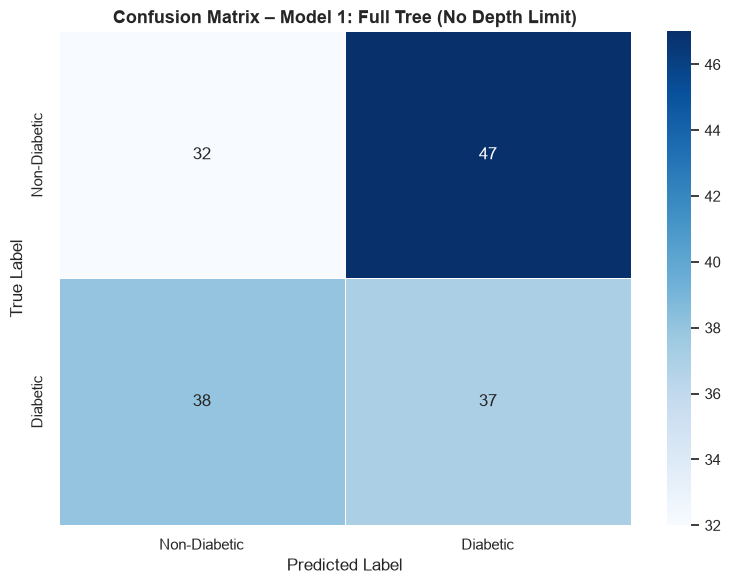

In [38]:
# --- Confusion Matrix: Model 1 ---
cm4_full = confusion_matrix(y4_test, y4_pred_full)

plt.figure(figsize=(8, 6))
sns.heatmap(cm4_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            linewidths=0.5)
plt.title('Confusion Matrix – Model 1: Full Tree (No Depth Limit)',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [39]:

# MODEL 2: Pruned Decision Tree
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X4_train, y4_train)

print("Model 2 – Pruned Decision Tree (max_depth=3) trained.")
print(f"  Tree depth    : {dt_pruned.get_depth()}")
print(f"  Number of leaves : {dt_pruned.get_n_leaves()}")

Model 2 – Pruned Decision Tree (max_depth=3) trained.
  Tree depth    : 3
  Number of leaves : 7


In [40]:
# --- Evaluate Model 2 ---
y4_pred_pr = dt_pruned.predict(X4_test)

acc_p  = accuracy_score(y4_test, y4_pred_pr)
prec_p = precision_score(y4_test, y4_pred_pr)
rec_p  = recall_score(y4_test, y4_pred_pr)
f1_p   = f1_score(y4_test, y4_pred_pr)

print("=" * 50)
print("  MODEL 2: Pruned Tree (max_depth=3) Metrics")
print("=" * 50)
print(f"  Accuracy  : {acc_p:.4f}  ({acc_p*100:.2f}%)")
print(f"  Precision : {prec_p:.4f}")
print(f"  Recall    : {rec_p:.4f}")
print(f"  F1-Score  : {f1_p:.4f}")
print("=" * 50)
print()
print("Classification Report (Pruned Tree):")
print(classification_report(y4_test, y4_pred_pr,
                             target_names=['Non-Diabetic', 'Diabetic']))

  MODEL 2: Pruned Tree (max_depth=3) Metrics
  Accuracy  : 0.4870  (48.70%)
  Precision : 0.4844
  Recall    : 0.8267
  F1-Score  : 0.6108

Classification Report (Pruned Tree):
              precision    recall  f1-score   support

Non-Diabetic       0.50      0.16      0.25        79
    Diabetic       0.48      0.83      0.61        75

    accuracy                           0.49       154
   macro avg       0.49      0.50      0.43       154
weighted avg       0.49      0.49      0.42       154



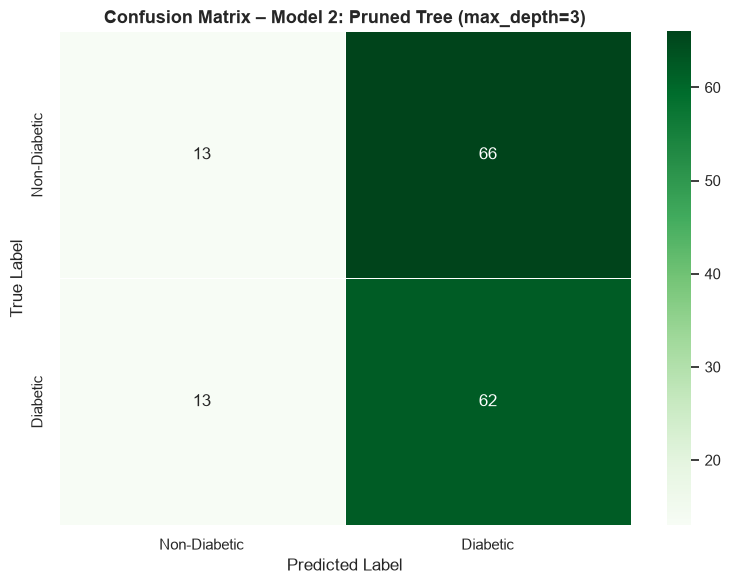

In [41]:
# --- Confusion Matrix: Model 2 ---
cm4_pr = confusion_matrix(y4_test, y4_pred_pr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm4_pr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            linewidths=0.5)
plt.title('Confusion Matrix – Model 2: Pruned Tree (max_depth=3)',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Evaluation Metrics – Model Comparison

In [42]:
comp = pd.DataFrame({
    'Model':     ['Full Tree (No Limit)', 'Pruned Tree (max_depth=3)'],
    'Depth':     [dt_full.get_depth(),    dt_pruned.get_depth()],
    'Leaves':    [dt_full.get_n_leaves(), dt_pruned.get_n_leaves()],
    'Accuracy':  [round(acc_f, 4),        round(acc_p, 4)],
    'Precision': [round(prec_f, 4),       round(prec_p, 4)],
    'Recall':    [round(rec_f, 4),        round(rec_p, 4)],
    'F1-Score':  [round(f1_f, 4),         round(f1_p, 4)]
})
print("Model Comparison Table:")
comp

Model Comparison Table:


,Model,Depth,Leaves,Accuracy,Precision,Recall,F1-Score
0,Full Tree (No Limit),20,143,0.4481,0.4405,0.4933,0.4654
1,Pruned Tree (max_depth=3),3,7,0.4870,0.4844,0.8267,0.6108
